# 08. Modellashtirish (Modeling)

Har bir guruh uchun o'tish balini bashorat qilamiz. Grant va shartnoma — alohida, har biri faqat kvotasi > 0 bo'lgan guruhlarda.

| Model | Tavsif |
|---|---|
| `median` | Baseline: o'qitish qismida bozor × asosiy yo'nalish bo'yicha median (topilmasa — bozor, keyin umumiy median) |
| `chegara` | Baseline, o'qitishsiz: bozorning taxminiy chegarasi (`bozor_*_chegara`) |
| `xgb_ball` | XGBoost, maqsad — xom o'tish bali |
| `xgb_ulush` | XGBoost, maqsad — `logit(ulush)`; bashorat ulushga, keyin `ulushdan_ballga` bilan ballga qaytariladi |

**Tekshirish:** 5-fold. Asosiy — `GroupKFold` OTM bo'yicha (model ko'rmagan OTM larda sinaladi, qattiqroq). Solishtirish uchun — tasodifiy `KFold` (keyingi yil OTM lar o'sha-o'sha bo'lishiga yaqinroq). **O'lchov:** MAE ballarda, qo'shimcha — xatosi 5 va 10 balldan kichik guruhlar ulushi.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import GroupKFold, KFold

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
print('xgboost', xgb.__version__)

xgboost 3.4.1


In [2]:
data = pd.read_csv('../data/processed/model_data.csv')
nomzodlar = pd.read_csv('../data/processed/nomzodlar.csv')
print(data.shape, nomzodlar.shape)

(5547, 31) (357561, 3)


## 1. Belgilar va yordamchi funksiyalar

In [3]:
KATEGORIAL = ['hudud', 'otm_nomi', 'asosiy_yunalish', 'talim_tili', 'talim_shakli',
              'fanlar_juftligi', 'bozor']
SONLI = ['tuman_kvotasi', 'grant_kvota_soni', 'shartnoma_kvota_soni', 'jami_kvota',
         'grant_kvota_ulushi', 'shartnoma_kvota_ulushi', 'asosiy_yunalish_guruhlar',
         'bozor_nomzodlar', 'bozor_q50', 'bozor_q75', 'bozor_q90', 'bozor_q95', 'bozor_189_soni',
         'bozor_grant_kvota', 'bozor_shartnoma_kvota', 'bozor_guruhlar', 'bozor_nomzod_orin',
         'bozor_grant_chegara', 'bozor_shartnoma_chegara']

# Kategoriyalar butun jadval bo'yicha qat'iy belgilanadi — foldlarda kodlar bir xil bo'lishi uchun
kategoriyalar = {c: pd.CategoricalDtype(sorted(data[c].unique())) for c in KATEGORIAL}

def belgilar(d, kategorial=KATEGORIAL):
    X = d[kategorial + SONLI].copy()
    for c in kategorial:
        X[c] = X[c].astype(kategoriyalar[c])
    X['tuman_kvotasi'] = X['tuman_kvotasi'].astype(int)
    return X

XGB_PARAMS = dict(n_estimators=600, learning_rate=0.05, max_depth=6, min_child_weight=10,
                  subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                  enable_categorical=True, max_cat_to_onehot=1, max_cat_threshold=8,
                  random_state=42, n_jobs=-1)

# GroupKFold da sinov OTM lari o'qitishda umuman yo'q — otm_nomi ni o'rganib bo'lmaydi
KATEGORIAL_OTMSIZ = [c for c in KATEGORIAL if c != 'otm_nomi']

print('Belgilar:', len(KATEGORIAL) + len(SONLI))

Belgilar: 26


In [4]:
# Ulush <-> ball o'girish (07-notebookdagi bilan bir xil)
bozor_ballar = {b: np.sort(g.to_numpy())[::-1]
                for b, g in nomzodlar.groupby('bozor')['toplagan_bali']}

def ulushdan_ballga(bozor, ulush):
    ballar = bozor_ballar[bozor]
    k = min(max(int(round(ulush * len(ballar))), 1), len(ballar))
    return ballar[k - 1]

EPS = 1e-4

def logit(u):
    u = np.clip(u, EPS, 1 - EPS)
    return np.log(u / (1 - u))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [5]:
def median_baseline(train, test, maqsad):
    umumiy = train[maqsad].median()
    bozor = train.groupby('bozor')[maqsad].median()
    bozor_yunalish = train.groupby(['bozor', 'asosiy_yunalish'])[maqsad].median()
    kalit = pd.MultiIndex.from_frame(test[['bozor', 'asosiy_yunalish']])
    p = pd.Series(bozor_yunalish.reindex(kalit).to_numpy(), index=test.index)
    p = p.fillna(test['bozor'].map(bozor)).fillna(umumiy)
    return p.to_numpy()

def cv_bashoratlar(d, tur, bolish, guruhlar=None, kategorial=KATEGORIAL):
    """Har bir model uchun out-of-fold bashoratlar (ballarda)."""
    bal, ulush = f'{tur}_bali', f'{tur}_ulush'
    X = belgilar(d, kategorial)
    oof = {m: np.full(len(d), np.nan) for m in ['median', 'chegara', 'xgb_ball', 'xgb_ulush']}
    oof['chegara'] = d[f'bozor_{tur}_chegara'].to_numpy()
    for tr, te in bolish.split(X, groups=guruhlar):
        oof['median'][te] = median_baseline(d.iloc[tr], d.iloc[te], bal)

        m = xgb.XGBRegressor(**XGB_PARAMS).fit(X.iloc[tr], d[bal].iloc[tr])
        oof['xgb_ball'][te] = m.predict(X.iloc[te])

        m = xgb.XGBRegressor(**XGB_PARAMS).fit(X.iloc[tr], logit(d[ulush].iloc[tr]))
        u = sigmoid(m.predict(X.iloc[te]))
        oof['xgb_ulush'][te] = [ulushdan_ballga(b, x) for b, x in zip(d['bozor'].iloc[te], u)]
    return pd.DataFrame(oof, index=d.index)

def baholash(haqiqiy, oof):
    xato = oof.sub(haqiqiy, axis=0).abs()
    return pd.DataFrame({
        'MAE': xato.mean(),
        'RMSE': np.sqrt((xato ** 2).mean()),
        '<=5 ball': (xato <= 5).mean(),
        '<=10 ball': (xato <= 10).mean(),
    }).round(3)

## 2. Nima uchun GroupKFold da `otm_nomi` ishlatilmaydi

Sinov foldidagi OTM lar o'qitishda yo'q. XGBoost ko'rilmagan kategoriyani daraxtning bir tomoniga tizimli yuboradi va bashorat bir tomonga siljiydi. Tekshiramiz (grant, xom ball):

In [6]:
d = data[data['grant_bali'].notna()].reset_index(drop=True)
for nom, kat in [('otm_nomi bilan', KATEGORIAL), ('otm_nomi siz', KATEGORIAL_OTMSIZ)]:
    X = belgilar(d, kat)
    oof = np.full(len(d), np.nan)
    for tr, te in GroupKFold(n_splits=5).split(X, groups=d['otm_nomi']):
        m = xgb.XGBRegressor(**XGB_PARAMS).fit(X.iloc[tr], d['grant_bali'].iloc[tr])
        oof[te] = m.predict(X.iloc[te])
    xato = oof - d['grant_bali']
    print(f"{nom:15s} MAE = {xato.abs().mean():5.2f}  o'rtacha siljish = {xato.mean():+.2f}")

otm_nomi bilan  MAE = 10.83  o'rtacha siljish = +0.85


otm_nomi siz    MAE =  9.84  o'rtacha siljish = -0.07


## 3. Kross-validatsiya

GroupKFold — `otm_nomi` siz; tasodifiy KFold — `otm_nomi` bilan (keyingi yil OTM lar o'sha-o'sha bo'ladi).

In [7]:
natijalar, oof_hammasi = {}, {}

for tur in ['grant', 'shartnoma']:
    d = data[data[f'{tur}_bali'].notna()].reset_index(drop=True)
    bolishlar = {
        'GroupKFold (OTM)': (GroupKFold(n_splits=5), d['otm_nomi'], KATEGORIAL_OTMSIZ),
        'KFold (tasodifiy)': (KFold(n_splits=5, shuffle=True, random_state=42), None, KATEGORIAL),
    }
    for nom, (bolish, guruhlar, kat) in bolishlar.items():
        oof = cv_bashoratlar(d, tur, bolish, guruhlar, kat)
        oof_hammasi[(tur, nom)] = oof.assign(haqiqiy=d[f'{tur}_bali'])
        natijalar[(tur, nom)] = baholash(d[f'{tur}_bali'], oof)
    print(f"{tur}: {len(d)} guruh — tayyor")

jadval = pd.concat(natijalar, names=['tur', 'bolish', 'model'])
jadval

grant: 3376 guruh — tayyor


shartnoma: 4718 guruh — tayyor


MAE    RMSE  <=5 ball  <=10 ball
tur       bolish            model                                         
grant     GroupKFold (OTM)  median      9.612  17.371     0.567      0.716
                            chegara    23.352  33.734     0.237      0.423
                            xgb_ball    9.844  14.933     0.436      0.654
                            xgb_ulush   9.376  15.251     0.506      0.703
          KFold (tasodifiy) median      9.307  16.917     0.583      0.723
                            chegara    23.352  33.734     0.237      0.423
                            xgb_ball    8.579  13.808     0.512      0.726
                            xgb_ulush   8.126  14.060     0.575      0.757
shartnoma GroupKFold (OTM)  median     16.329  26.971     0.433      0.571
                            chegara    20.281  30.997     0.381      0.499
                            xgb_ball   13.105  20.727     0.433      0.596
                            xgb_ulush  13.113  22.488     0.496      0.633
          KFold (tasodifiy) median     15.801  25.728     0.442      0.573
                            chegara    20.281  30.997     0.381      0.499
                            xgb_ball   12.734  20.032     0.439      0.604
                            xgb_ulush  12.562  21.711     0.504      0.648

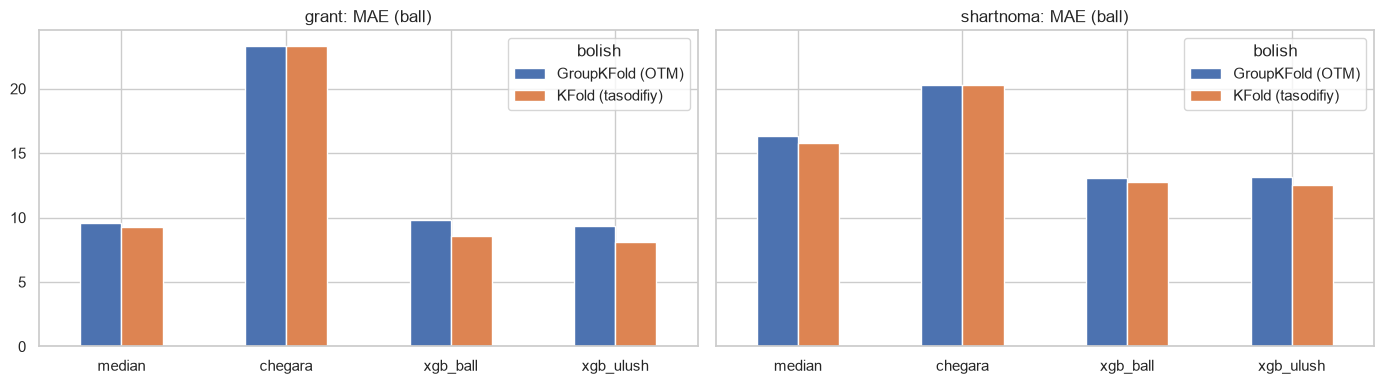

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, tur in zip(axes, ['grant', 'shartnoma']):
    j = jadval.loc[tur, 'MAE'].unstack(0)
    j.plot.bar(ax=ax, rot=0)
    ax.set_title(f'{tur}: MAE (ball)')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 4. Eng yaxshi model xatolarining tahlili (GroupKFold)

In [9]:
def xato_kesim(tur, model, col):
    oof = oof_hammasi[(tur, 'GroupKFold (OTM)')]
    d = data[data[f'{tur}_bali'].notna()].reset_index(drop=True)
    xato = (oof[model] - oof['haqiqiy']).abs()
    return (pd.DataFrame({col: d[col], 'xato': xato, 'haqiqiy': oof['haqiqiy']})
              .groupby(col).agg(guruhlar=('xato', 'size'), MAE=('xato', 'mean'),
                                o_rtacha_ball=('haqiqiy', 'mean'))
              .round(2).sort_values('guruhlar', ascending=False))

eng_yaxshi = {tur: jadval.loc[(tur, 'GroupKFold (OTM)'), 'MAE'].idxmin() for tur in ['grant', 'shartnoma']}
print('Eng yaxshi modellar:', eng_yaxshi)

Eng yaxshi modellar: {'grant': 'xgb_ulush', 'shartnoma': 'xgb_ball'}


In [10]:
xato_kesim('grant', eng_yaxshi['grant'], 'talim_shakli')

,guruhlar,MAE,o_rtacha_ball
talim_shakli,,,
Kunduzgi,3369,9.32,140.23
Masofaviy,4,32.92,139.80
Kechki,3,44.80,70.70


In [11]:
xato_kesim('shartnoma', eng_yaxshi['shartnoma'], 'talim_shakli')

,guruhlar,MAE,o_rtacha_ball
talim_shakli,,,
Kunduzgi,3369,14.70,91.26
Kechki,881,9.67,79.79
Masofaviy,439,8.45,68.65
Dual,29,2.77,58.71


In [12]:
xato_kesim('grant', eng_yaxshi['grant'], 'bozor').head(12)

,guruhlar,MAE,o_rtacha_ball
bozor,,,
Matematika + Fizika,916,12.14,105.92
Biologiya + Kimyo,688,8.28,158.90
Kasbiy (ijodiy imtihon) + Kasbiy (ijodiy imtihon),581,10.26,152.77
Ingliz tili + Ona tili va adabiyoti,225,4.25,181.90
Kimyo + Biologiya,182,11.60,113.04
Matematika + Chet tili,164,5.86,176.19
Biologiya + Ona tili va adabiyoti,102,5.42,134.27
Tarix + Ona tili va adabiyoti,78,7.57,161.35
Ona tili va adabiyoti + Chet tili,57,4.12,174.18


In [13]:
xato_kesim('shartnoma', eng_yaxshi['shartnoma'], 'bozor').head(12)

,guruhlar,MAE,o_rtacha_ball
bozor,,,
Matematika + Fizika,1436,4.64,62.02
Matematika + Chet tili,747,18.36,91.43
Kasbiy (ijodiy imtihon) + Kasbiy (ijodiy imtihon),675,19.94,96.76
Biologiya + Kimyo,379,17.75,88.57
Ingliz tili + Ona tili va adabiyoti,301,7.35,166.11
Biologiya + Ona tili va adabiyoti,232,10.11,76.74
Kimyo + Biologiya,210,13.13,70.82
Tarix + Geografiya,97,13.01,73.10
Tarix + Chet tili,96,32.66,119.38


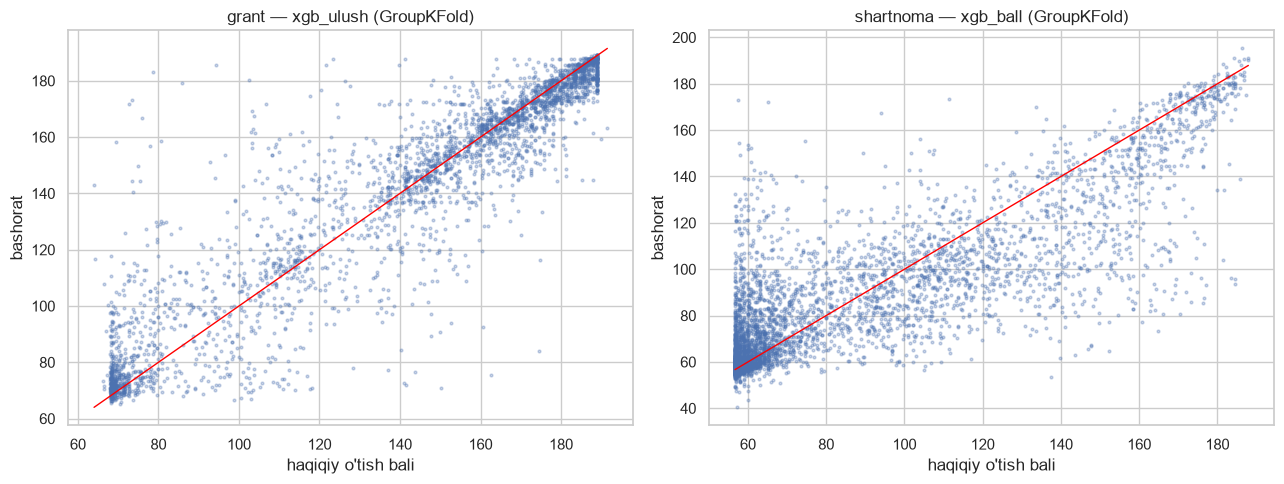

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, tur in zip(axes, ['grant', 'shartnoma']):
    oof = oof_hammasi[(tur, 'GroupKFold (OTM)')]
    ax.scatter(oof['haqiqiy'], oof[eng_yaxshi[tur]], s=4, alpha=0.3)
    chiziq = [oof['haqiqiy'].min(), oof['haqiqiy'].max()]
    ax.plot(chiziq, chiziq, color='red', lw=1)
    ax.set_xlabel('haqiqiy o\'tish bali')
    ax.set_ylabel('bashorat')
    ax.set_title(f'{tur} — {eng_yaxshi[tur]} (GroupKFold)')
plt.tight_layout()
plt.show()

## 5. Yakuniy modellar va belgilar ahamiyati

Butun ma'lumotda, `otm_nomi` bilan o'qitiladi (keyingi yil OTM lar ma'lum). Ahamiyat — `gain` bo'yicha.

In [15]:
modellar, ahamiyat = {}, {}
for tur in ['grant', 'shartnoma']:
    d = data[data[f'{tur}_bali'].notna()].reset_index(drop=True)
    X = belgilar(d)
    modellar[(tur, 'ball')] = xgb.XGBRegressor(**XGB_PARAMS).fit(X, d[f'{tur}_bali'])
    modellar[(tur, 'ulush')] = xgb.XGBRegressor(**XGB_PARAMS).fit(X, logit(d[f'{tur}_ulush']))
    for maqsad in ['ball', 'ulush']:
        g = modellar[(tur, maqsad)].get_booster().get_score(importance_type='gain')
        ahamiyat[f'{tur}_{maqsad}'] = pd.Series(g)

ahamiyat = pd.DataFrame(ahamiyat)
(ahamiyat / ahamiyat.sum()).round(3).sort_values('grant_ball', ascending=False)

,grant_ball,grant_ulush,shartnoma_ball,shartnoma_ulush
bozor_q90,0.428,0.249,0.081,0.004
bozor_q50,0.313,0.144,0.183,0.002
bozor_grant_chegara,0.150,0.086,0.003,0.099
bozor_q95,0.047,0.001,0.001,0.007
bozor_grant_kvota,0.020,0.069,NaN,0.001
bozor_shartnoma_chegara,0.009,NaN,0.464,0.331
bozor_nomzod_orin,0.009,0.109,0.034,0.367
asosiy_yunalish,0.005,0.015,0.007,0.012
bozor,0.004,0.037,0.114,0.015
asosiy_yunalish_guruhlar,0.004,0.029,0.004,0.005


## 6. Saqlash

In [16]:
from pathlib import Path

Path('../models').mkdir(exist_ok=True)
for (tur, maqsad), m in modellar.items():
    m.save_model(f'../models/{tur}_{maqsad}.json')

oof_df = pd.concat({f'{t} | {b}': o for (t, b), o in oof_hammasi.items()}, names=['tur_bolish', 'qator'])
oof_df.to_csv('../data/processed/oof_bashoratlar.csv', encoding='utf-8')
jadval.to_csv('../reports/cv_natijalar.csv', encoding='utf-8')
print(sorted(p.name for p in Path('../models').glob('*.json')))

['grant_ball.json', 'grant_ulush.json', 'shartnoma_ball.json', 'shartnoma_ulush.json']


## Xulosa

| MAE (ball) | Grant, GroupKFold | Grant, KFold | Shartnoma, GroupKFold | Shartnoma, KFold |
|---|---|---|---|---|
| `median` (baseline) | 9.61 | 9.31 | 16.33 | 15.80 |
| `chegara` (o'qitishsiz) | 23.35 | 23.35 | 20.28 | 20.28 |
| `xgb_ball` | 9.84 | 8.58 | **13.11** | 12.73 |
| `xgb_ulush` | **9.38** | **8.13** | 13.11 | **12.56** |

- **Grant:** XGBoost baseline dan ozgina yaxshi (GroupKFold: 9.61 → 9.38; KFold: 9.31 → 8.13). Bozor × asosiy yo'nalish medianasi allaqachon juda kuchli — grant bali asosan "qaysi yo'nalish, qaysi bozor" bilan belgilanadi. Nisbiy maqsad (`xgb_ulush`) xom balldan yaxshiroq.
- **Shartnoma:** XGBoost baseline dan sezilarli yaxshi (16.33 → 13.11, ~20%). Xom ball va ulush deyarli teng.
- **`otm_nomi` va GroupKFold:** ko'rilmagan OTM uchun `otm_nomi` bashoratni siljitadi (2-bo'lim), shuning uchun GroupKFold da ishlatilmaydi. Yakuniy modellarda bor, chunki keyingi yil OTM lar ma'lum.
- **Taxminiy chegara** o'zi yakka baseline sifatida yomon (23 ball), lekin model ichida muhim belgi.
- **Katta xatolar:** grant — Kechki/Masofaviy (jami 7 guruh), shartnoma — `Tarix + Chet tili`, `Tarix + Ona tili va adabiyoti`, `Ona tili va adabiyoti + Matematika` bozorlari (MAE 24–33).

### Muhim cheklov
Eng muhim belgilar — bozor darajasidagi (`bozor_q90`, `bozor_q50`, `bozor_*_chegara`). Ular bitta yil ichida faqat 32 xil qiymat oladi, ya'ni amalda bozor identifikatori vazifasini bajaradi. Bozorning raqobati o'zgarganda (keyingi yil) model qanday javob berishini bitta yil ma'lumoti bilan tekshirib bo'lmaydi. Nisbiy maqsad (`xgb_ulush`) aynan shu uchun kerak: u taqsimot o'zgarishiga avtomatik moslashadi.